In [ ]:
!pip install -q transformers datasets accelerate scikit-learn matplotlib pandas tensorflow

In [ ]:
# --- Cell 1: Libraries & Setup ---
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Setup Complete. TensorFlow Version:", tf.__version__)

Setup Complete. TensorFlow Version: 2.20.0


In [ ]:
# --- Cell 2: File Upload & Data Preprocessing ---
from google.colab import files

print("Apni CSV file upload karein (Combined Data ya Advanced wali):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load Data
df = pd.read_csv(file_name)

# Auto-Fix Columns (Error yahan aata tha, ab nahi aayega)
if 'statement' in df.columns and 'status' in df.columns:
    df = df.rename(columns={'statement': 'text', 'status': 'label'})
    print("Columns auto-corrected from 'statement/status' to 'text/label'")

# Remove null rows
df = df.dropna(subset=['text', 'label'])

# Keep only target classes
allowed_labels = ["Depression", "Anxiety", "Stress", "Bipolar", "Suicidal", "Normal"]
df = df[df['label'].isin(allowed_labels)].copy()

# Text Cleaning Function
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['cleaned_text'] = df['text'].apply(clean_text)

print(f"\nData Ready! Total Rows: {len(df)}")
print(df[['cleaned_text', 'label']].head())

Apni CSV file upload karein (Combined Data ya Advanced wali):


Saving mental_health_advanced_50k.csv to mental_health_advanced_50k.csv

Data Ready! Total Rows: 51604
                                        cleaned_text    label
0                                         oh my gosh  Anxiety
1  trouble sleeping confused mind restless heart ...  Anxiety
2  all wrong back off dear forward doubt stay in ...  Anxiety
3  ive shifted my focus to something else but im ...  Anxiety
4  im restless and restless its been a month now ...  Anxiety


In [ ]:
# --- Cell 3: Encoding & Splitting ---
# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)

# Split 80% Train, 20% Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_text'], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Keras ke liye categorical format
y_train_keras = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_keras = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

print("Classes Mapping:", dict(zip(le.classes_, range(NUM_CLASSES))))

Classes Mapping: {'Anxiety': 0, 'Bipolar': 1, 'Depression': 2, 'Normal': 3, 'Stress': 4, 'Suicidal': 5}


In [ ]:
# --- Cell 4: Tokenization ---
VOCAB_SIZE = 20000
MAX_LENGTH = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LENGTH, padding='post')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LENGTH, padding='post')

print(f"X_train shape: {X_train_padded.shape}")

X_train shape: (41283, 100)


In [ ]:
# --- Cell 5: GloVe Initialization ---
EMBEDDING_DIM = 100

if not os.path.exists('glove.6B.100d.txt'):
    print("Downloading GloVe weights...")
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip
else:
    print("GloVe weights found locally.")

embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]

print("GloVe matrix ready!")

GloVe matrix ready!


In [ ]:
# --- Cell 6: Model Architecture ---
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, weights=[embedding_matrix], input_length=MAX_LENGTH, trainable=True),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 233s 348ms/step - accuracy: 0.5276 - loss: 1.2697 - val_accuracy: 0.6631 - val_loss: 0.7834 - learning_rate: 0.0010
Epoch 2/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 225s 349ms/step - accuracy: 0.6704 - loss: 0.7949 - val_accuracy: 0.7496 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 3/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 266s 356ms/step - accuracy: 0.7434 - loss: 0.6443 - val_accuracy: 0.7770 - val_loss: 0.5400 - learning_rate: 0.0010
Epoch 4/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 256s 347ms/step - accuracy: 0.7747 - loss: 0.5689 - val_accuracy: 0.7871 - val_loss: 0.5156 - learning_rate: 0.0010
Epoch 5/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 226s 350ms/step - accuracy: 0.7984 - loss: 0.5165 - val_accuracy: 0.7945 - val_loss: 0.5042 - learning_rate: 0.0010
Epoch 6/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 270s 361ms/step - accuracy: 0.8191 - loss: 0.4686 - val_accuracy: 0.7880 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 7/15
646/646 ━━━━━━━━━━━━━━━━━━━━ 235s 364ms/step - accura

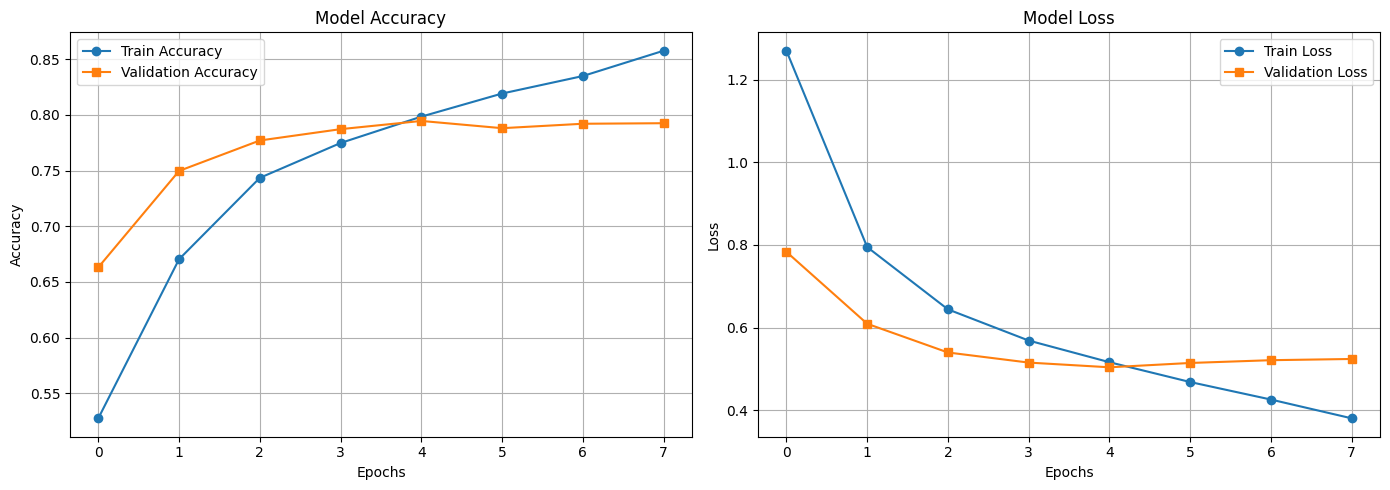

In [ ]:
# --- Cell 7: Training & Plotting Graphs ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5)
]

history = model.fit(
    X_train_padded, y_train_keras,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_padded, y_test_keras),
    callbacks=callbacks
)

# Plot Graphs (For your Project Report)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

323/323 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step

--- Classification Report ---
              precision    recall  f1-score   support

     Anxiety       0.83      0.79      0.81       768
     Bipolar       0.78      0.74      0.76       555
  Depression       0.76      0.74      0.75      3081
      Normal       0.94      0.93      0.93      3269
      Stress       0.56      0.69      0.62       517
    Suicidal       0.69      0.71      0.70      2131

    accuracy                           0.79     10321
   macro avg       0.76      0.77      0.76     10321
weighted avg       0.80      0.79      0.80     10321



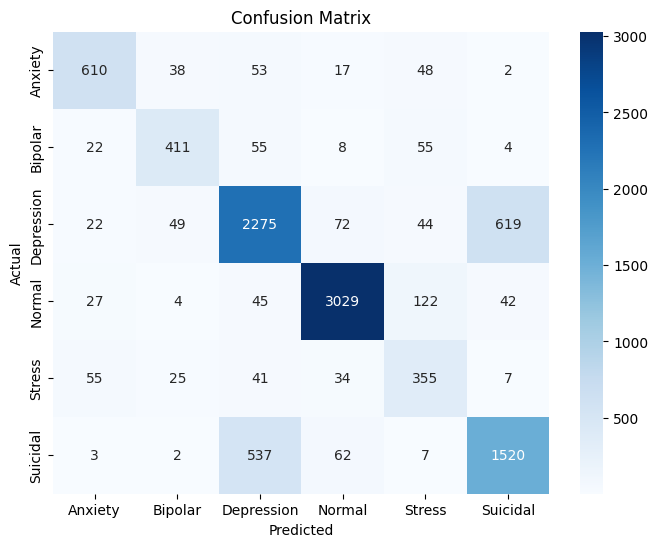

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

--- Live Test ---
Input: Feeling so restless lately.
Predicted Class: Anxiety (Confidence: 99.63%)


In [ ]:
# --- Cell 8: Evaluation & Confusion Matrix ---
predictions = model.predict(X_test_padded)
y_pred_classes = np.argmax(predictions, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Live Test
test_sentence = "Feeling so restless lately."
seq = tokenizer.texts_to_sequences([clean_text(test_sentence)])
padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post')
res = model.predict(padded)[0]
idx = np.argmax(res)

print("\n--- Live Test ---")
print(f"Input: {test_sentence}")
print(f"Predicted Class: {le.inverse_transform([idx])[0]} (Confidence: {res[idx]*100:.2f}%)")

In [ ]:
# --- Cell 9: Exporting the Modern Model and Encoders ---
import pickle

# 1. Save model in the new native Keras format (fixes the warning)
model.save('mental_health_bilstm.keras')

# 2. Save the Tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 3. Save the Label Encoder (Fixed variable name to 'le')
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model (.keras), Tokenizer (.pkl), and Encoder (.pkl) safely exported!")

✅ Model (.keras), Tokenizer (.pkl), and Encoder (.pkl) safely exported!
